# Rehan Khan || 221A059 || 21

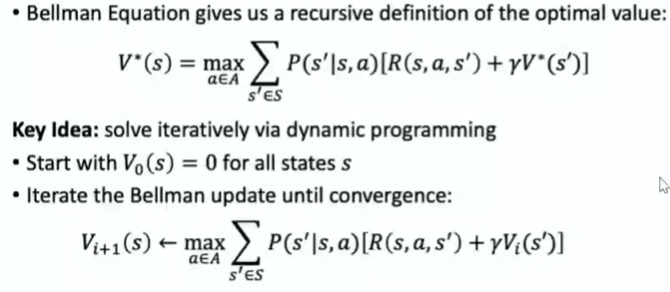

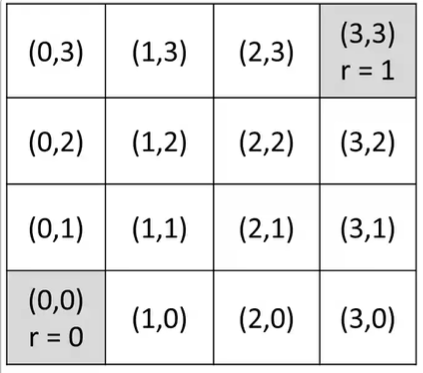

In [10]:
print("Rehan Khan || 221A059")


def value_iteration(states, actions, transition_model, reward_function, gamma, epsilon):
    # Initialize value function
    V = {s: 0 for s in states}

    while True:
        delta = 0
        for s in states:
            v = V[s]
            V[s] = max(sum(transition_model(s, a, s_next) * (reward_function(s, a, s_next) + gamma * V[s_next])
                       for s_next in states) for a in actions)
            delta = max(delta, abs(v - V[s]))
        #check for convergence
        if delta < epsilon * (1 - gamma) / gamma:
            break
    # Extract optimal policy
    policy = {}
    for s in states:
        policy[s] = max(actions,
                        key=lambda a: sum(
                            transition_model(s, a, s_next) * (reward_function(s, a, s_next) + gamma * V[s_next])
                            for s_next in states))

    return policy, V

Rehan Khan || 221A059


In [11]:
print("Rehan Khan || 221A059")
import numpy as np

Rehan Khan || 221A059


In [12]:
print("Rehan Khan || 221A059")
# Define Grid World Parameters
grid_size = (4, 4)
states = [(i, j) for i in range(grid_size[0]) for j in range(grid_size[1])]
actions = ['up', 'down', 'left', 'right']

Rehan Khan || 221A059


In [13]:
print("Rehan Khan || 221A059")
states

Rehan Khan || 221A059


[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [14]:
print("Rehan Khan || 221A059")
# Define Rewards and Terminal States
rewards = {(0, 0): 0, (3, 3): 1}
terminal_states = [(0, 0), (3, 3)]

Rehan Khan || 221A059


In [15]:
print("Rehan Khan || 221A059")
# Transition probabilities
def transition(state, action):
    if state in terminal_states:
        return {state: 1.0} # Stays in terminal state

    i, j = state
    if action == 'up':
        next_state = (max(i - 1, 0), j) # Uses max() to prevent agent move above the leftmost cell.
    elif action == 'down':
        next_state = (min(i + 1, grid_size[0] - 1), j) # Uses min() to prevent agent beyond the rightmost cell.
    elif action == 'left':
        next_state = (i, max(j - 1, 0)) # Uses max() to prevent agent move beyond the bottommost cell.
    elif action == 'right':
        next_state = (i, min(j + 1, grid_size[1] - 1)) # Uses min() to prevent agent move beyond the topmost cell.

    return {next_state: 1.0}

Rehan Khan || 221A059


In [16]:
print("Rehan Khan || 221A059")
# Policy Iteration Algorithm
def policy_iteration(states, actions, gamma=0.9, theta=1e-6):
    policy = {s: np.random.choice(actions) for s in states if s not in terminal_states}
    V = {s: 0 for s in states}

    while True:
        # Policy Evaluation
        while True:
            delta = 0
            for s in states:
                if s in terminal_states:
                    continue
                v = V[s]
                a = policy[s]
                next_states = transition(s, a)
                V[s] = sum(prob * (rewards.get(ns, 0) + gamma * V[ns]) for ns, prob in next_states.items())
                delta = max(delta, abs(v - V[s]))
            if delta < theta:
                break

        # Policy Improvement
        policy_stable = True
        for s in states:
            if s in terminal_states:
                continue

            old_action = policy[s]
            action_values = {}
            for a in actions:
                next_states = transition(s, a)
                action_values[a] = sum(prob * (rewards.get(ns, 0) + gamma * V[ns]) for ns, prob in next_states.items())

            best_action = max(action_values, key=action_values.get)
            policy[s] = best_action

            if old_action != best_action:
                policy_stable = False

        if policy_stable:
            break

    return policy, V



Rehan Khan || 221A059


In [17]:
print("Rehan Khan || 221A059")
# Run Policy Iteration
policy, V = policy_iteration(states, actions)

# Display Results
print("Optimal Policy:")
for i in range(grid_size[0]):
    print([policy.get((i, j), '-') for j in range(grid_size[1])])

print("\nState Values:")
for i in range(grid_size[0]):
    print([round(V[(i, j)], 2) for j in range(grid_size[1])])

Rehan Khan || 221A059
Optimal Policy:
['-', 'down', 'down', 'down']
['down', 'down', 'down', 'down']
['down', 'down', 'down', 'down']
['right', 'right', 'right', '-']

State Values:
[0, 0.66, 0.73, 0.81]
[0.66, 0.73, 0.81, 0.9]
[0.73, 0.81, 0.9, 1.0]
[0.81, 0.9, 1.0, 0]
